In [ ]:
from pathlib import Path
import pandas as pd

HERE = Path.cwd()
ROOT = HERE if (HERE / "data").exists() else HERE.parent

csv_path = ROOT / "data" / "raw" / "survey_response_original_file.csv"
df = pd.read_csv(csv_path, encoding="utf-8")
df.sample(10)



---
# PART 1: Quick EDA
---




In [ ]:
# Distribution of responses with and without comment comments over the 3-year period

(df.groupby("year")["has_comment"].value_counts(normalize=True) * 100).round(2)

year  has_comment
2023  True           84.72
      False          15.28
2024  True           85.30
      False          14.70
2025  True           85.90
      False          14.10
Name: proportion, dtype: float64

In [ ]:
df.describe()

,survey_response_id,employee_scd_id,year,recommendation_rating
count,4391.000000,4.391000e+03,4391.000000,4391.000000
mean,2196.000000,2.024054e+08,2024.043726,7.947165
std,1267.716845,8.161810e+04,0.815511,1.262545
min,1.000000,2.023000e+08,2023.000000,3.000000
25%,1098.500000,2.023015e+08,2023.000000,7.000000
50%,2196.000000,2.024011e+08,2024.000000,8.000000
75%,3293.500000,2.025007e+08,2025.000000,9.000000
max,4391.000000,2.025022e+08,2025.000000,10.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4391 entries, 0 to 4390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   survey_response_id     4391 non-null   int64 
 1   employee_scd_id        4391 non-null   int64 
 2   year                   4391 non-null   int64 
 3   recommendation_rating  4391 non-null   int64 
 4   comment                3747 non-null   object
 5   has_comment            4391 non-null   bool  
dtypes: bool(1), int64(4), object(1)
memory usage: 175.9+ KB




---
# PART 2: Adding the enps_category column
---


In [ ]:
# function to assign the category (promoter, neutral, or detractor) based on the eNPS score

def enps_category(score):
  if score <= 6:
    return "detractor"
  elif score <= 8:
    return "passive"
  else:
    return "promoter"

In [ ]:
df["enps_category"]=df["recommendation_rating"].apply(enps_category)
df.sample(5)

,survey_response_id,employee_scd_id,year,recommendation_rating,comment,has_comment,enps_category
362,363,202301376,2023,8,I see real chances to progress based on merit ...,True,passive
3183,3184,202501562,2025,9,"Recognition and coaching are consistent, which...",True,promoter
659,660,202301502,2023,7,I worry about competitiveness and the pace of ...,True,passive
2666,2667,202401851,2024,9,I appreciate the trust and autonomy; the manag...,True,promoter
1945,1946,202400821,2024,6,I would like more structured development and t...,True,detractor


---
# PART 3: Adding the sentiment_score column using VADER and SentimentIntensityAnalyzer
---


**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool specifically designed for short texts such as survey responses, social media posts, or customer feedback.

It is particularly effective at capturing:

- Polarity (positive, neutral, negative)

- Intensity of sentiment

- Linguistic nuances such as capitalization, punctuation, degree modifiers, and negations.

**SentimentIntensityAnalyzer** is the main VADER component used to compute sentiment scores.
It returns four metrics:

- positive: proportion of positive sentiment

- neutral: proportion of neutral sentiment

- negative: proportion of negative sentiment

compound: a normalized score between -1 (most negative) and +1 (most positive), commonly used as an overall sentiment score.

In [ ]:
# installation NLTK
!pip -q install nltk

In [ ]:
# Importing VADER and downloading the sentiment lexicon
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Downloading the VADER sentiment lexicon
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Initializing the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [ ]:
# Test on a single sentence
test_text = "The projects are interesting, but workload can be intense at times."

sia.polarity_scores(test_text)

{'neg': 0.0, 'neu': 0.732, 'pos': 0.268, 'compound': 0.3182}

In [ ]:
# Initializing the new column
# Creating the column with a default value
df["sentiment_score"] = 0.0

In [ ]:
# Apply VADER only to comments

mask = df["has_comment"] == True # Selecting only rows with comments

df.loc[mask, "sentiment_score"] = (
    df.loc[mask, "comment"]
      .astype(str) # Safety check to avoid potential errors
      .apply(lambda x: sia.polarity_scores(x)["compound"]) # Applying VADER row by row ("compound" = final normalized score)
)

In [ ]:
# Verifying the output:
df[["recommendation_rating", "sentiment_score", "comment"]].sample(10, random_state=1)

,recommendation_rating,sentiment_score,comment
3767,8,0.8519,Work conditions are good overall and hybrid wo...
3052,10,0.8754,I appreciate the increased transparency from l...
518,8,0.9118,Learning opportunities and projects help me bu...
3189,8,0.7717,I can maintain a healthy balance most of the t...
4219,7,0.1513,I would like more visibility from leadership a...
3312,9,0.9562,Digital tools and processes are improving and ...
4376,10,0.9432,Skapa remains attractive with interesting miss...
791,7,0.0000,NaN
3023,10,0.7003,"I feel aligned with the values, especially inc..."
4362,7,0.0000,NaN


In [ ]:
df["sentiment_score"].describe()

,sentiment_score
count,4391.000000
mean,0.482971
std,0.427273
min,-0.851900
25%,0.000000
50%,0.670500
75%,0.855500
max,0.973600


In [ ]:
import matplotlib.pyplot as plt

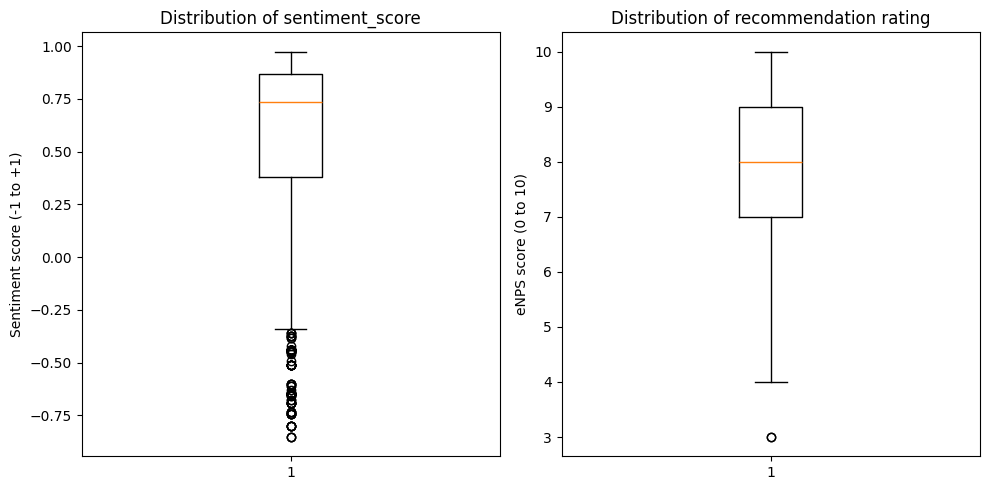

In [ ]:
# Data (comments only)
df_v = df[df["has_comment"] == True]

sentiment = df_v["sentiment_score"]
enps = df_v["recommendation_rating"]

# Create the figure with two subplots
plt.figure(figsize=(10, 5))

# Plot 1: sentiment_score distribution
plt.subplot(1, 2, 1)
plt.boxplot(sentiment.dropna())
plt.title("Distribution of sentiment_score")
plt.ylabel("Sentiment score (-1 to +1)")

# Plot 2: eNPS score distribution
plt.subplot(1, 2, 2)
plt.boxplot(enps.dropna())
plt.title("Distribution of recommendation rating")
plt.ylabel("eNPS score (0 to 10)")

plt.tight_layout()
plt.show()

---
# PART 4: Adding the sentiment_final column
---


**Explanations**


*   Here, I compute a score that combines both the eNPS rating and the sentiment_score, weighted by whether negative expressions are detected in the comment (expressions that I manually identified to improve the results).

*   This produces a score called score_combined, which is then used to determine the final sentiment: positive, to be determined (mixed or ambiguous comment), negative, or NaN (when no comment is provided).

## 4.1 Score normalization

In [ ]:
# eNPS scaled to [0, 1]
df["enps_norm"] = df["recommendation_rating"] / 10

# Sentiment scaled to [0, 1]
df["sentiment_norm"] = ((df["sentiment_score"].fillna(0) + 1) / 2)

## 4.2 HR negative signal dictionary and detection

In [ ]:
negative_cues = [
    "would like",
    "like more",
    "could be",
    "not always",
    "it would help",
    "it would be helpful",
    "feels slow",
    "slow compared",
    "pace with inflation",
    "inflation",
    "sustained pressure",
    "pressure can lead",
    "lead to fatigue",
    "fatigue",
    "burnout",
    "can be intense",
    "early signs of burnout",
    "top down",
    "clearer expectations",
    "more transparency",
    "unclear",
    "criteria for promotion",
    "promotion criteria",
    "processes are slow",
    "create friction",
    "siloed",
    "work life balance could improve",
    "balance could improve",
    "overtime can become",
    "inconsistent",
    "late",
    "uncertainty",
    "limited",
    "slow",
    "less meaningful",
    "worry about"
]

def has_negative_signal(text):
    text = str(text).lower()
    return any(kw in text for kw in negative_cues) # Iterate over all keywords in negative_cues and check whether at least one is present.
# If so, return TRUE; otherwise, return FALSE.

# 0/1
df["negative_signal"] = df["comment"].apply(has_negative_signal).astype(int) # Creating a column called negative_signal

In [ ]:
df

,survey_response_id,employee_scd_id,year,recommendation_rating,comment,has_comment,enps_category,sentiment_score,enps_norm,sentiment_norm,negative_signal
0,1,202301141,2023,9,Team spirit is strong and the atmosphere is fr...,True,promoter,0.9100,0.9,0.95500,0
1,2,202300500,2023,7,Pay progression feels slow compared with respo...,True,passive,-0.3400,0.7,0.33000,1
2,3,202301553,2023,8,Innovation and a forward-looking strategy make...,True,passive,0.9246,0.8,0.96230,0
3,4,202301348,2023,8,Supportive leadership and clear feedback make ...,True,passive,0.8957,0.8,0.94785,0
4,5,202301554,2023,9,Innovation and a forward-looking strategy make...,True,promoter,0.9477,0.9,0.97385,0
...,...,...,...,...,...,...,...,...,...,...,...
4386,4387,202500720,2025,8,I can maintain a healthy balance most of the t...,True,passive,0.9442,0.8,0.97210,0
4387,4388,202500150,2025,10,I appreciate the increased transparency from l...,True,promoter,0.9478,1.0,0.97390,0
4388,4389,202501654,2025,5,I would like more regular coaching and clearer...,True,detractor,0.3612,0.5,0.68060,1
4389,4390,202500361,2025,8,Compensation feels competitive for the market ...,True,passive,0.1779,0.8,0.58895,0


## 4.3 Creation of the combined score

If no comment is provided, apply enps_norm

In [ ]:
penalty = 0.12  # To be adjusted if needed

# Combined score = 60% eNPS + 40% sentiment
base_score = 0.6 * df["enps_norm"] + 0.4 * df["sentiment_norm"]

# If no comment -> score = enps_norm
# Otherwise -> score = base_score - penalty * negative_signal
df["combined_score"] = df["enps_norm"]  # default value for rows without comment

mask_text = df["has_comment"] == True
df.loc[mask_text, "combined_score"] = (
    base_score[mask_text] - penalty * df.loc[mask_text, "negative_signal"]
)

# Bounded between 0 and 1
df["combined_score"] = df["combined_score"].clip(0, 1)

df[["has_comment","recommendation_rating","sentiment_score","negative_signal","combined_score"]].head(10)

,has_comment,recommendation_rating,sentiment_score,negative_signal,combined_score
0,True,9,0.9100,0,0.92200
1,True,7,-0.3400,1,0.43200
2,True,8,0.9246,0,0.86492
3,True,8,0.8957,0,0.85914
4,True,9,0.9477,0,0.92954
5,True,8,0.8225,0,0.84450
6,True,10,0.8689,0,0.97378
7,True,6,0.0772,1,0.45544
8,True,8,0.6705,0,0.81410
9,True,8,0.8126,0,0.84252


In [ ]:
df[df["has_comment"] == True] \
  .groupby("recommendation_rating")["negative_signal"] \
  .sum() \
  .sort_index()

# Distribution of negative_signal by rating
# No negative_signal observed for recommendation rating of 8 and above

,negative_signal
recommendation_rating,
3,2
4,16
5,83
6,331
7,705
8,0
9,0
10,0


In [ ]:
# Percentage distribution of negative_signal by rating
neg_by_score = df[df["has_comment"] == True].groupby("recommendation_rating")["negative_signal"].mean().mul(100).round(2)
neg_by_score

,negative_signal
recommendation_rating,
3,100.00
4,100.00
5,93.26
6,91.18
7,92.89
8,0.00
9,0.00
10,0.00


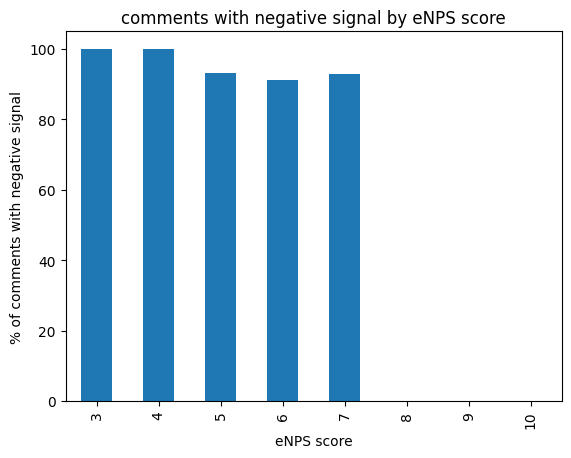

In [ ]:
import matplotlib.pyplot as plt # Distribution of negative_signal by rating

neg_by_score.plot(kind="bar")
plt.title("comments with negative signal by eNPS score")
plt.ylabel("% of comments with negative signal")
plt.xlabel("eNPS score")
plt.show()

In [ ]:
# Comments with to be determined or unclear sentiment are predominantly observed for combined scores ranging between 0.62 and 0.70, according to human interpretability.

(df[(df["has_comment"] == True) &
    (df["combined_score"].between(0.62, 0.70))]
    .sort_values("combined_score")
    .drop_duplicates(subset="comment")
    [["year", "combined_score","recommendation_rating", "sentiment_score", "comment", "negative_signal"]]
)

,year,combined_score,recommendation_rating,sentiment_score,comment,negative_signal
492,2023,0.62006,7,0.6003,"Onboarding and integration were smooth, and th...",1
804,2023,0.62006,7,0.6003,Work-life balance could improve; overtime can ...,1
2072,2024,0.62006,7,0.6003,Sometimes the work feels less meaningful when ...,1
2695,2024,0.62248,7,0.6124,"Onboarding and integration were smooth, and th...",1
780,2023,0.62498,7,0.6249,Sustained pressure can lead to fatigue and I’v...,1
...,...,...,...,...,...,...
1182,2023,0.68708,7,0.9354,The values are stated clearly but not always r...,1
3853,2025,0.68742,7,0.9371,The employer brand could be stronger to attrac...,1
2459,2024,0.68884,7,0.9442,I would like more structured development and t...,1
3053,2025,0.68884,7,0.9442,Team spirit is strong and the atmosphere is fr...,1


In [ ]:
# Function used to determine the final sentiment of the comment (or leave it as "to be determined" for "ambiguous" cases)

import numpy as np

def sentiment_final(row):
    # Case 1: no comment provided = no textual sentiment available
    if not row["has_comment"]:
        return np.nan

    # Case 2: when a comment is available, the combined_score is used
    score = row["combined_score"]

    if score >= 0.70:
        return "positive" # 100% positive
    elif score >= 0.62:
        return "to be determined" #
    else:
        return "negative" # 100% negative

df["sentiment_final"] = df.apply(sentiment_final, axis=1)

In [ ]:
df.sample(10)

,survey_response_id,employee_scd_id,year,recommendation_rating,comment,has_comment,enps_category,sentiment_score,enps_norm,sentiment_norm,negative_signal,combined_score,sentiment_final
3735,3736,202500120,2025,8,Innovation and a forward-looking strategy make...,True,passive,0.3818,0.8,0.69090,0,0.75636,positive
1716,1717,202400425,2024,9,I’m satisfied with my pay and the overall bene...,True,promoter,0.8979,0.9,0.94895,0,0.91958,positive
858,859,202301300,2023,9,Compensation feels competitive for the market ...,True,promoter,0.6142,0.9,0.80710,0,0.86284,positive
3613,3614,202502144,2025,7,Recent uncertainty in priorities makes the lon...,True,passive,-0.0240,0.7,0.48800,1,0.49520,negative
2019,2020,202401057,2024,10,"I feel aligned with the values, especially inc...",True,promoter,0.7196,1.0,0.85980,0,0.94392,positive
2852,2853,202500799,2025,8,Learning opportunities and projects help me bu...,True,passive,0.8225,0.8,0.91125,0,0.84450,positive
572,573,202300334,2023,7,Team spirit is strong and the atmosphere is fr...,True,passive,0.8555,0.7,0.92775,0,0.79110,positive
3227,3228,202500237,2025,9,NaN,False,promoter,0.0000,0.9,0.50000,0,0.90000,NaN
955,956,202300887,2023,6,I worry about competitiveness and the pace of ...,True,detractor,-0.4404,0.6,0.27980,1,0.35192,negative
3265,3266,202500655,2025,7,Team spirit is strong and the atmosphere is fr...,True,passive,0.8402,0.7,0.92010,1,0.66804,to be determined


In [ ]:
(df["sentiment_final"].value_counts(normalize=True) * 100).round(2)

,proportion
sentiment_final,
positive,67.28
negative,27.73
to be determined,4.99


In [ ]:
df["sentiment_final"].isna().sum() # 644 responses do not contain a comment and therefore have no sentiment_final

np.int64(644)

In [ ]:
# Columns to be removed
cols_to_drop = [
    "sentiment_score",
    "enps_norm",
    "sentiment_norm",
    "negative_signal",
    "combined_score"
]

df = df.drop(columns=cols_to_drop, errors="ignore").copy()

# Rename sentiment_final to sentiment
df = df.rename(columns={"sentiment_final": "sentiment"})

# Quick check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4391 entries, 0 to 4390
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   survey_response_id     4391 non-null   int64 
 1   employee_scd_id        4391 non-null   int64 
 2   year                   4391 non-null   int64 
 3   recommendation_rating  4391 non-null   int64 
 4   comment                3747 non-null   object
 5   has_comment            4391 non-null   bool  
 6   enps_category          4391 non-null   object
 7   sentiment              3747 non-null   object
dtypes: bool(1), int64(4), object(3)
memory usage: 244.5+ KB


In [ ]:
df.sample(5)

,survey_response_id,employee_scd_id,year,recommendation_rating,comment,has_comment,enps_category,sentiment
1844,1845,202400526,2024,8,Innovation and a forward-looking strategy make...,True,passive,positive
1086,1087,202300184,2023,7,Pay progression feels slow compared with respo...,True,passive,negative
1511,1512,202400482,2024,10,I appreciate the trust and autonomy; the manag...,True,promoter,positive
3807,3808,202501341,2025,9,Learning opportunities and projects help me bu...,True,promoter,positive
2302,2303,202400926,2024,8,"Recognition and coaching are consistent, which...",True,passive,positive


In [ ]:
df_to_be_determined = df[df["sentiment"] == "to be determined"]
df_to_be_determined

,survey_response_id,employee_scd_id,year,recommendation_rating,comment,has_comment,enps_category,sentiment
39,40,202300696,2023,7,The employer brand could be stronger to attrac...,True,passive,to be determined
46,47,202301183,2023,8,Career paths are becoming clearer and internal...,True,passive,to be determined
81,82,202300298,2023,7,I would like more regular coaching and clearer...,True,passive,to be determined
109,110,202301123,2023,7,Team spirit is strong and the atmosphere is fr...,True,passive,to be determined
114,115,202300776,2023,7,"Onboarding and integration were smooth, and th...",True,passive,to be determined
...,...,...,...,...,...,...,...,...
4258,4259,202501894,2025,7,The employer brand could be stronger to attrac...,True,passive,to be determined
4263,4264,202500465,2025,7,Pay progression feels slow compared with respo...,True,passive,to be determined
4272,4273,202500378,2025,7,Bench periods and project allocation could be ...,True,passive,to be determined
4345,4346,202500695,2025,7,I would like more regular coaching and clearer...,True,passive,to be determined


**Info :** The output of this DataFrame is saved in the file 01_sentiment_analysis_done.csv (path: data > nlp_transformed).
Sentiments labeled “to be determined” will be analyzed sentence by sentence in Part 2 to determine whether they are 100% positive, 100% negative, or mixed (see part_2_topicanalysis_gh.ipynb).